# Are Open LLM Leaderboard Rankings Real?
### An audit of Open LLM model rankings

The Open LLM Leaderboard ranks models using an average of six benchmark scores and presents
them as an ordered list — #1, #2, #3, ... #4576. This notebook asks one question:
**how many of those ranks are statistically distinguishable from each other?**

We also ask whether the six benchmarks measure six different things, or whether some are so
correlated they double-count the same signal.

**The answer is conservative and uncomfortable.** With honest statistics — clustered standard
errors for the subtask benchmarks, correlation-aware error propagation, and strict
overlap-based tiering — 4,576 ranked models collapse into a small number of statistically
distinguishable tiers. Every assumption we make pushes toward *fewer* real tiers, so the
count we report is a floor, not a ceiling.

**No new models are trained. No money spent. Just public data and honest statistics.**

---
## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, os
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

---
## 1. Load the Leaderboard Data (summary scores)

The `contents` dataset has one row per model with the six final benchmark scores.
This is the summary view

In [20]:
from datasets import load_dataset

ds = load_dataset("open-llm-leaderboard/contents", split="train")
df_raw = ds.to_pandas()
df_raw.head(2)

,eval_name,Precision,Type,T,Weight type,Architecture,Model,fullname,Model sha,Average ⬆️,...,MUSR Raw,MUSR,MMLU-PRO Raw,MMLU-PRO,Merged,Official Providers,Upload To Hub Date,Submission Date,Generation,Base Model
0,0-hero_Matter-0.2-7B-DPO_bfloat16,bfloat16,"💬 chat models (RLHF, DPO, IFT, ...)",💬,Original,MistralForCausalLM,"<a target=""_blank"" href=""https://huggingface.c...",0-hero/Matter-0.2-7B-DPO,26a66f0d862e2024ce4ad0a09c37052ac36e8af6,8.906361,...,0.381375,5.871875,0.116356,1.817376,False,False,2024-04-13,2024-08-05,0,0-hero/Matter-0.2-7B-DPO
1,01-ai_Yi-1.5-34B_bfloat16,bfloat16,🟢 pretrained,🟢,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.c...",01-ai/Yi-1.5-34B,4b486f81c935a2dadde84c6baa1e1370d40a098f,25.646494,...,0.423604,11.217188,0.466589,40.732122,False,True,2024-05-11,2024-06-12,0,01-ai/Yi-1.5-34B


---
## 2. Clean, Normalize, and Drop Incomplete Models

We keep the six benchmark **Raw** scores (proportions, 0–1), the overall average,
model name, and parameter count.

- **Raw scores are already proportions (0–1).** Only `Average ⬆️` is a 0–100 percentage and needs dividing.

In [21]:
BENCH_RAW = {
    "GPQA":     "GPQA Raw",
    "MMLU_PRO": "MMLU-PRO Raw",
    "MATH":     "MATH Lvl 5 Raw",
    "BBH":      "BBH Raw",
    "IFEval":   "IFEval Raw",
    "MUSR":     "MUSR Raw",
}

# Question counts (used for Wilson benchmarks + reference)
# MUSR: murder mysteries (250) + object placements (256) + team allocation (250) = 756
BENCH_N = {
    "GPQA": 448, "MMLU_PRO": 12032, "MATH": 1324,
    "BBH": 6511, "IFEval": 541, "MUSR": 756,
}

cols_keep = {
    "fullname": "model", "#Params (B)": "params_b", "Average ⬆️": "avg_score",
    **{v: k for k, v in BENCH_RAW.items()}
}
df = df_raw[list(cols_keep.keys())].rename(columns=cols_keep).copy()

bench_cols = list(BENCH_RAW.keys())

# Raw scores already 0–1; only avg_score is a percentage
for b in bench_cols:
    df[b] = pd.to_numeric(df[b], errors="coerce")
df["avg_score"] = pd.to_numeric(df["avg_score"], errors="coerce") / 100.0
df["params_b"]  = pd.to_numeric(df["params_b"], errors="coerce")

# Drop models with ANY missing benchmark
before = len(df)
df = df.dropna(subset=bench_cols, how="any").reset_index(drop=True)
print(f"Dropped {before - len(df)} incomplete models; {len(df)} remain")

# Original leaderboard rank
df = df.sort_values("avg_score", ascending=False).reset_index(drop=True)
df["orig_rank"] = df.index + 1

print("\nScore ranges (sanity check — should be realistic proportions):")
for b in bench_cols:
    print(f"  {b:10s}: {df[b].min():.3f} – {df[b].max():.3f}  (n questions = {BENCH_N[b]:,})")

Dropped 0 incomplete models; 4576 remain

Score ranges (sanity check — should be realistic proportions):
  GPQA      : 0.206 – 0.471  (n questions = 448)
  MMLU_PRO  : 0.100 – 0.730  (n questions = 12,032)
  MATH      : 0.000 – 0.715  (n questions = 1,324)
  BBH       : 0.218 – 0.827  (n questions = 6,511)
  IFEval    : 0.000 – 0.900  (n questions = 541)
  MUSR      : 0.293 – 0.602  (n questions = 756)


---
## 2.5 Pull Subtask Detail for Clustered Standard Errors

BBH and MUSR are not single tests but averages across subtasks (BBH has 23, MUSR has 3).
Treating them as one flat pool understates uncertainty because it ignores the variation
*between* subtasks.

We pull per-subtask scores from the detailed `results` dataset and compute **clustered standard
errors**, combining within-subtask sampling noise and between-subtask spread. This follows the
clustered-SE recommendation in Miller (2024), *Adding Error Bars to Evals*.

GPQA, MMLU-PRO, and MATH stay as flat proportions (Wilson). IFEval is left flat and disclosed
as a limitation, since its prompt/instruction nesting is messier to model.

In [22]:
from huggingface_hub import HfApi
api = HfApi()
repo = "open-llm-leaderboard/results"

files = api.list_repo_files(repo, repo_type="dataset")
json_files = [f for f in files if f.endswith(".json")]

model_files = defaultdict(list)
for f in json_files:
    model_files[f.rsplit("/", 1)[0]].append(f)
latest_file = {m: sorted(fl)[-1] for m, fl in model_files.items()}
print(f"Found {len(json_files)} files across {len(latest_file)} unique models")

Found 10509 files across 4508 unique models


In [23]:
from huggingface_hub import hf_hub_download

CACHE = "subtask_scores.csv"

def clustered_se(scores, ses):
    """
    SE for a benchmark whose score is the MEAN of k subtask accuracies.
    The leaderboard DEFINES the score as this mean, so the only uncertainty
    is the within-subtask sampling error, propagated through the mean:
        Var(mean) = (1/k^2) * sum(se_i^2)
    """
    scores = np.asarray(scores, dtype=float)
    ses = np.asarray([0.0 if (s is None or s == "N/A") else s for s in ses], dtype=float)
    k = len(scores)
    if k == 0:
        return np.nan, np.nan
    var_within = np.sum(ses**2) / (k**2)
    return scores.mean(), np.sqrt(var_within)

def parse_one(local_path):
    with open(local_path) as fh:
        data = json.load(fh)
    res = data.get("results", {})
    out = {}
    for parent, prefix in [("BBH", "leaderboard_bbh_"), ("MUSR", "leaderboard_musr_")]:
        scores, ses = [], []
        for key, val in res.items():
            if key.startswith(prefix):
                sc = val.get("acc_norm,none")
                se = val.get("acc_norm_stderr,none")
                if sc is not None:
                    scores.append(sc); ses.append(se)
        mean_sc, clust = clustered_se(scores, ses)
        out[f"{parent}_score_clustered"] = mean_sc
        out[f"{parent}_se"] = clust
        out[f"{parent}_nsubtasks"] = len(scores)
    return out

if os.path.exists(CACHE):
    sub_df = pd.read_csv(CACHE)
    print(f"Loaded cached subtask scores: {len(sub_df)} models")
else:
    rows, total = [], len(latest_file)
    for i, (model_id, fpath) in enumerate(latest_file.items()):
        try:
            local = hf_hub_download(repo, fpath, repo_type="dataset")
            parsed = parse_one(local)
            parsed["model"] = model_id
            rows.append(parsed)
        except Exception:
            pass
        if (i + 1) % 250 == 0:
            print(f"  {i+1}/{total} processed...")
    sub_df = pd.DataFrame(rows)
    sub_df.to_csv(CACHE, index=False)
    print(f"✓ Parsed {len(sub_df)} models, cached to {CACHE}")

sub_df.head()

Loaded cached subtask scores: 3744 models


,BBH_score_clustered,BBH_se,BBH_nsubtasks,MUSR_score_clustered,MUSR_se,MUSR_nsubtasks,model
0,0.359625,0.006031,24,0.381375,0.017398,3,0-hero/Matter-0.2-7B-DPO
1,0.601569,0.006031,24,0.439823,0.017795,3,01-ai/Yi-1.5-34B-32K
2,0.610022,0.005993,24,0.439760,0.017863,3,01-ai/Yi-1.5-34B-Chat-16K
3,0.608375,0.006076,24,0.428198,0.017542,3,01-ai/Yi-1.5-34B-Chat
4,0.597639,0.005960,24,0.423604,0.017688,3,01-ai/Yi-1.5-34B


In [24]:
# Reconciliation: do subtask means reconstruct the aggregate scores?
check = df.merge(sub_df, on="model", how="inner")
print(f"Matched {len(check)} models on name\n")
for b in ["BBH", "MUSR"]:
    diff = (check[b] - check[f"{b}_score_clustered"]).abs()
    print(f"  {b}: median |aggregate - reconstructed| = {diff.median():.4f}")

Matched 3807 models on name

  BBH: median |aggregate - reconstructed| = 0.0000
  MUSR: median |aggregate - reconstructed| = 0.0000


In [25]:
# Merge clustered SEs into the main dataframe
df = df.merge(
    sub_df[["model", "BBH_se", "MUSR_se", "BBH_score_clustered", "MUSR_score_clustered"]],
    on="model", how="left"
)
matched = df["BBH_se"].notna().sum()
print(f"Clustered SE attached to {matched} / {len(df)} models")

# Drop the few models with no subtask match (can't compute honest CI for them)
df = df.dropna(subset=["BBH_se", "MUSR_se"]).reset_index(drop=True)
df = df.sort_values("avg_score", ascending=False).reset_index(drop=True)
df["orig_rank"] = df.index + 1
print(f"Final analysis set: {len(df)} models with complete clustered data")

Clustered SE attached to 3807 / 4576 models
Final analysis set: 3802 models with complete clustered data


---
## 3. Compute Confidence Intervals

| Benchmark | Method | Why |
|-----------|--------|-----|
| GPQA | Wilson | Single flat proportion |
| MMLU-PRO | Wilson | Single flat proportion |
| MATH Lvl 5 | Wilson | Single flat proportion |
| IFEval | Wilson | Flat proportion (clustering disclosed as limitation) |
| BBH | **Clustered SE** | Mean across 23 subtasks of unequal size |
| MUSR | **Clustered SE** | Mean across 3 subtasks with large between-subtask spread |

The **Wilson interval** handles proportions near 0 and 1 better than the textbook formula.
The **clustered SE** (computed in Section 2.5) is the rigorous treatment for subtask-averaged
benchmarks — it is wider than a naive flat-proportion interval, which is the honest result.

In [26]:
from scipy.stats import norm
Z = 1.96  # 95%

def wilson_ci(p, n):
    if pd.isna(p) or pd.isna(n) or n == 0:
        return (np.nan, np.nan)
    p = np.clip(p, 0, 1)
    denom = 1 + Z**2 / n
    centre = (p + Z**2 / (2*n)) / denom
    margin = (Z / denom) * np.sqrt(p*(1-p)/n + Z**2/(4*n**2))
    return (max(0, centre - margin), min(1, centre + margin))

WILSON_BENCHES    = ["GPQA", "MMLU_PRO", "MATH", "IFEval"]
CLUSTERED_BENCHES = ["BBH", "MUSR"]

for bench in WILSON_BENCHES:
    n = BENCH_N[bench]
    cis = df[bench].apply(lambda p: wilson_ci(p, n))
    df[f"{bench}_lo"]    = cis.apply(lambda x: x[0])
    df[f"{bench}_hi"]    = cis.apply(lambda x: x[1])
    df[f"{bench}_width"] = df[f"{bench}_hi"] - df[f"{bench}_lo"]
    df[f"{bench}_se"]    = df[f"{bench}_width"] / (2 * Z)
    print(f"{bench} (Wilson, n={n:,})")

for bench in CLUSTERED_BENCHES:
    se_col = f"{bench}_se"
    df[f"{bench}_lo"]    = (df[bench] - Z * df[se_col]).clip(lower=0)
    df[f"{bench}_hi"]    = (df[bench] + Z * df[se_col]).clip(upper=1)
    df[f"{bench}_width"] = df[f"{bench}_hi"] - df[f"{bench}_lo"]
    print(f"{bench} (Clustered SE across subtasks)")

print("\nCI width summary (percentage points):")
for bench in bench_cols:
    w = df[f"{bench}_width"].dropna() * 100
    print(f"  {bench:10s}: median ±{w.median()/2:.2f}pp  |  max ±{w.max()/2:.2f}pp")

GPQA (Wilson, n=448)
MMLU_PRO (Wilson, n=12,032)
MATH (Wilson, n=1,324)
IFEval (Wilson, n=541)
BBH (Clustered SE across subtasks)
MUSR (Clustered SE across subtasks)

CI width summary (percentage points):
  GPQA      : median ±4.21pp  |  max ±4.60pp
  MMLU_PRO  : median ±0.85pp  |  max ±0.89pp
  MATH      : median ±1.63pp  |  max ±2.69pp
  BBH       : median ±1.21pp  |  max ±1.85pp
  IFEval    : median ±3.95pp  |  max ±4.20pp
  MUSR      : median ±3.42pp  |  max ±5.53pp


---
## 4. Propagate Uncertainty to the Average — Correlation-Aware

The leaderboard average is the mean of six benchmark scores. The naive way to combine
their uncertainties assumes the benchmarks are **independent**:

```
SE_avg = sqrt( sum(SE_i²) ) / k        # WRONG when benchmarks are correlated
```

But they are not independent — BBH and MMLU-PRO correlate at ~0.95. Positive correlation
*increases* the true variance of the average. We use the full covariance form:

```
Var(avg) = (1/k²) · Σ_ij  ρ_ij · SE_i · SE_j
```

This yields slightly **wider** intervals than the independence formula — which means *more*
tier collapse, not less. Our result is therefore conservative.

In [27]:
# Correlation matrix estimated once from the population of scores
corr_matrix = df[bench_cols].corr(method="pearson").values
k = len(bench_cols)

se_cols = [f"{b}_se" for b in bench_cols]
SE = df[se_cols].values  # (n_models, 6)

# Var(avg) = (1/k^2) * row · Corr · row   for each model's SE vector
avg_se = np.array([
    np.sqrt((row[None, :] * corr_matrix * row[:, None]).sum()) / k
    for row in SE
])
df["avg_se"]    = avg_se
df["avg_lo"]    = df["avg_score"] - Z * df["avg_se"]
df["avg_hi"]    = df["avg_score"] + Z * df["avg_se"]
df["avg_width"] = df["avg_hi"] - df["avg_lo"]

w = df["avg_width"].dropna() * 100
print("Combined average CI half-width (correlation-aware):")
print(f"  Median: ±{w.median()/2:.2f}pp")
print(f"  Mean:   ±{w.mean()/2:.2f}pp")
print(f"  Max:    ±{w.max()/2:.2f}pp")

print("\nTop 20 models — score with 95% CI:")
t = df.head(20)[["model", "avg_score", "avg_lo", "avg_hi"]].copy()
t["disp"] = t.apply(lambda r: f"{r.avg_score*100:.1f}%  [{r.avg_lo*100:.1f}, {r.avg_hi*100:.1f}]", axis=1)
t["short"] = t["model"].str.split("/").str[-1].str[:40]
print(t[["short", "disp"]].to_string(index=False))

Combined average CI half-width (correlation-aware):
  Median: ±2.09pp
  Mean:   ±2.05pp
  Max:    ±2.49pp

Top 20 models — score with 95% CI:
                                   short                disp
                  calme-3.2-instruct-78b 52.1%  [50.0, 54.2]
                  calme-3.1-instruct-78b 51.3%  [49.2, 53.4]
                  CalmeRys-78B-Orpo-v0.1 51.2%  [49.1, 53.4]
                       calme-2.4-rys-78b 50.8%  [48.6, 52.9]
        Qwen2.5-72B-Instruct-abliterated 48.1%  [46.0, 50.2]
                    Qwen2.5-72B-Instruct 48.0%  [45.9, 50.1]
                   calme-2.1-qwen2.5-72b 47.9%  [45.7, 50.0]
                  Homer-v1.0-Qwen2.5-72B 47.5%  [45.2, 49.7]
                     qwen2.5-test-32b-it 47.4%  [45.2, 49.5]
   Linkbricks-Horizon-AI-Avengers-V1-32B 47.3%  [45.2, 49.5]
                   calme-2.2-qwen2.5-72b 47.2%  [45.1, 49.4]
     Qwen2.5-32B-Instruct-abliterated-v2 46.9%  [44.7, 49.0]
                             ultiima-72B 46.8%  [44.5, 49.0]
zeta

---
## 5. Collapse Rankings into Real Statistical Tiers

**The core finding.**

A model joins the current tier only if its CI overlaps with the **anchor** meaning the highest-scoring
model that started that tier. We compare each model's CI upper bound against the anchor's lower
bound. If they don't overlap, the model is genuinely distinguishable from the best in the tier
and starts a new tier.

**Why anchor-based, not a running boundary?** If A overlaps B and B overlaps C, that does *not*
mean A and C are indistinguishable. Grouping them anyway is transitivity — a logical error. A
model earns its tier by being indistinguishable from the *top* of that tier, not just its neighbour.

In [28]:
def assign_tiers(df_sorted):
    tiers, tier_id = [], 1
    anchor_lo = df_sorted.iloc[0]["avg_lo"]
    for _, row in df_sorted.iterrows():
        if row["avg_hi"] < anchor_lo:   # can't reach the anchor — new tier
            tier_id += 1
            anchor_lo = row["avg_lo"]
        tiers.append(tier_id)
    return tiers

df_valid = df.dropna(subset=["avg_lo", "avg_hi"]).copy()
df_valid = df_valid.sort_values("avg_score", ascending=False).reset_index(drop=True)
df_valid["tier"] = assign_tiers(df_valid)

n_tiers, n_models = df_valid["tier"].max(), len(df_valid)
print(f"Models analysed:    {n_models:,}")
print(f"Original ranks:     {n_models:,}")
print(f"Statistical tiers:  {n_tiers:,}")
print(f"Compression:        {n_models/n_tiers:.0f}x  (~{n_models/n_tiers:.0f} models per real rank)")

ts = df_valid["tier"].value_counts().sort_index()
print(f"\nMedian models per tier: {ts.median():.0f}")
print(f"Largest tier:           {ts.max()} models")
print(f"Tiers with >10 models:  {(ts > 10).sum()}")

Models analysed:    3,802
Original ranks:     3,802
Statistical tiers:  13
Compression:        292x  (~292 models per real rank)

Median models per tier: 271
Largest tier:           700 models
Tiers with >10 models:  12


---
## 6. Visualisations

### 6a. CI width by benchmark (at p=0.5, the fairest comparison point)

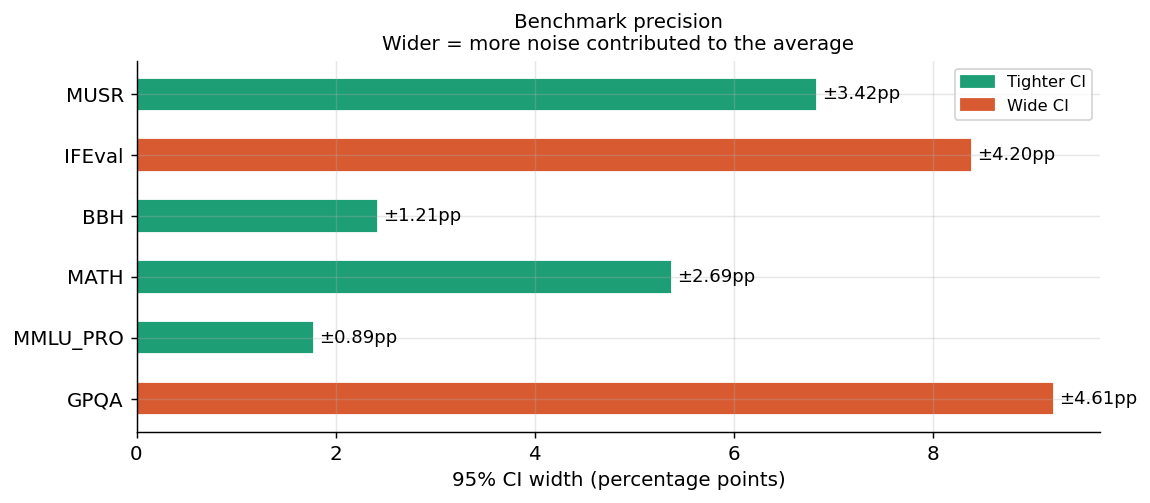

Saved fig1_ci_width.png


In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = bench_cols

ref = []
for b in labels:
    if b in WILSON_BENCHES:
        lo, hi = wilson_ci(0.5, BENCH_N[b])
        ref.append((hi - lo) * 100)
    else:
        # clustered: use median observed SE → width
        ref.append(df[f"{b}_se"].median() * 2 * Z * 100)

colors = ["#D85A30" if b in ["IFEval", "GPQA"] else "#1D9E75" for b in labels]
bars = ax.barh(labels, ref, color=colors, height=0.55, edgecolor="white")
for bar, w in zip(bars, ref):
    ax.text(w + 0.05, bar.get_y()+bar.get_height()/2, f"±{w/2:.2f}pp", va="center", fontsize=10)

ax.set_xlabel("95% CI width (percentage points)")
ax.set_title("Benchmark precision\nWider = more noise contributed to the average", fontsize=11)
ax.legend(handles=[mpatches.Patch(color="#1D9E75", label="Tighter CI"),
                   mpatches.Patch(color="#D85A30", label="Wide CI")], fontsize=9)
plt.tight_layout(); plt.savefig("fig1_ci_width.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved fig1_ci_width.png")

### 6b. Top 50 models: point estimate + 95% CI, coloured by tier

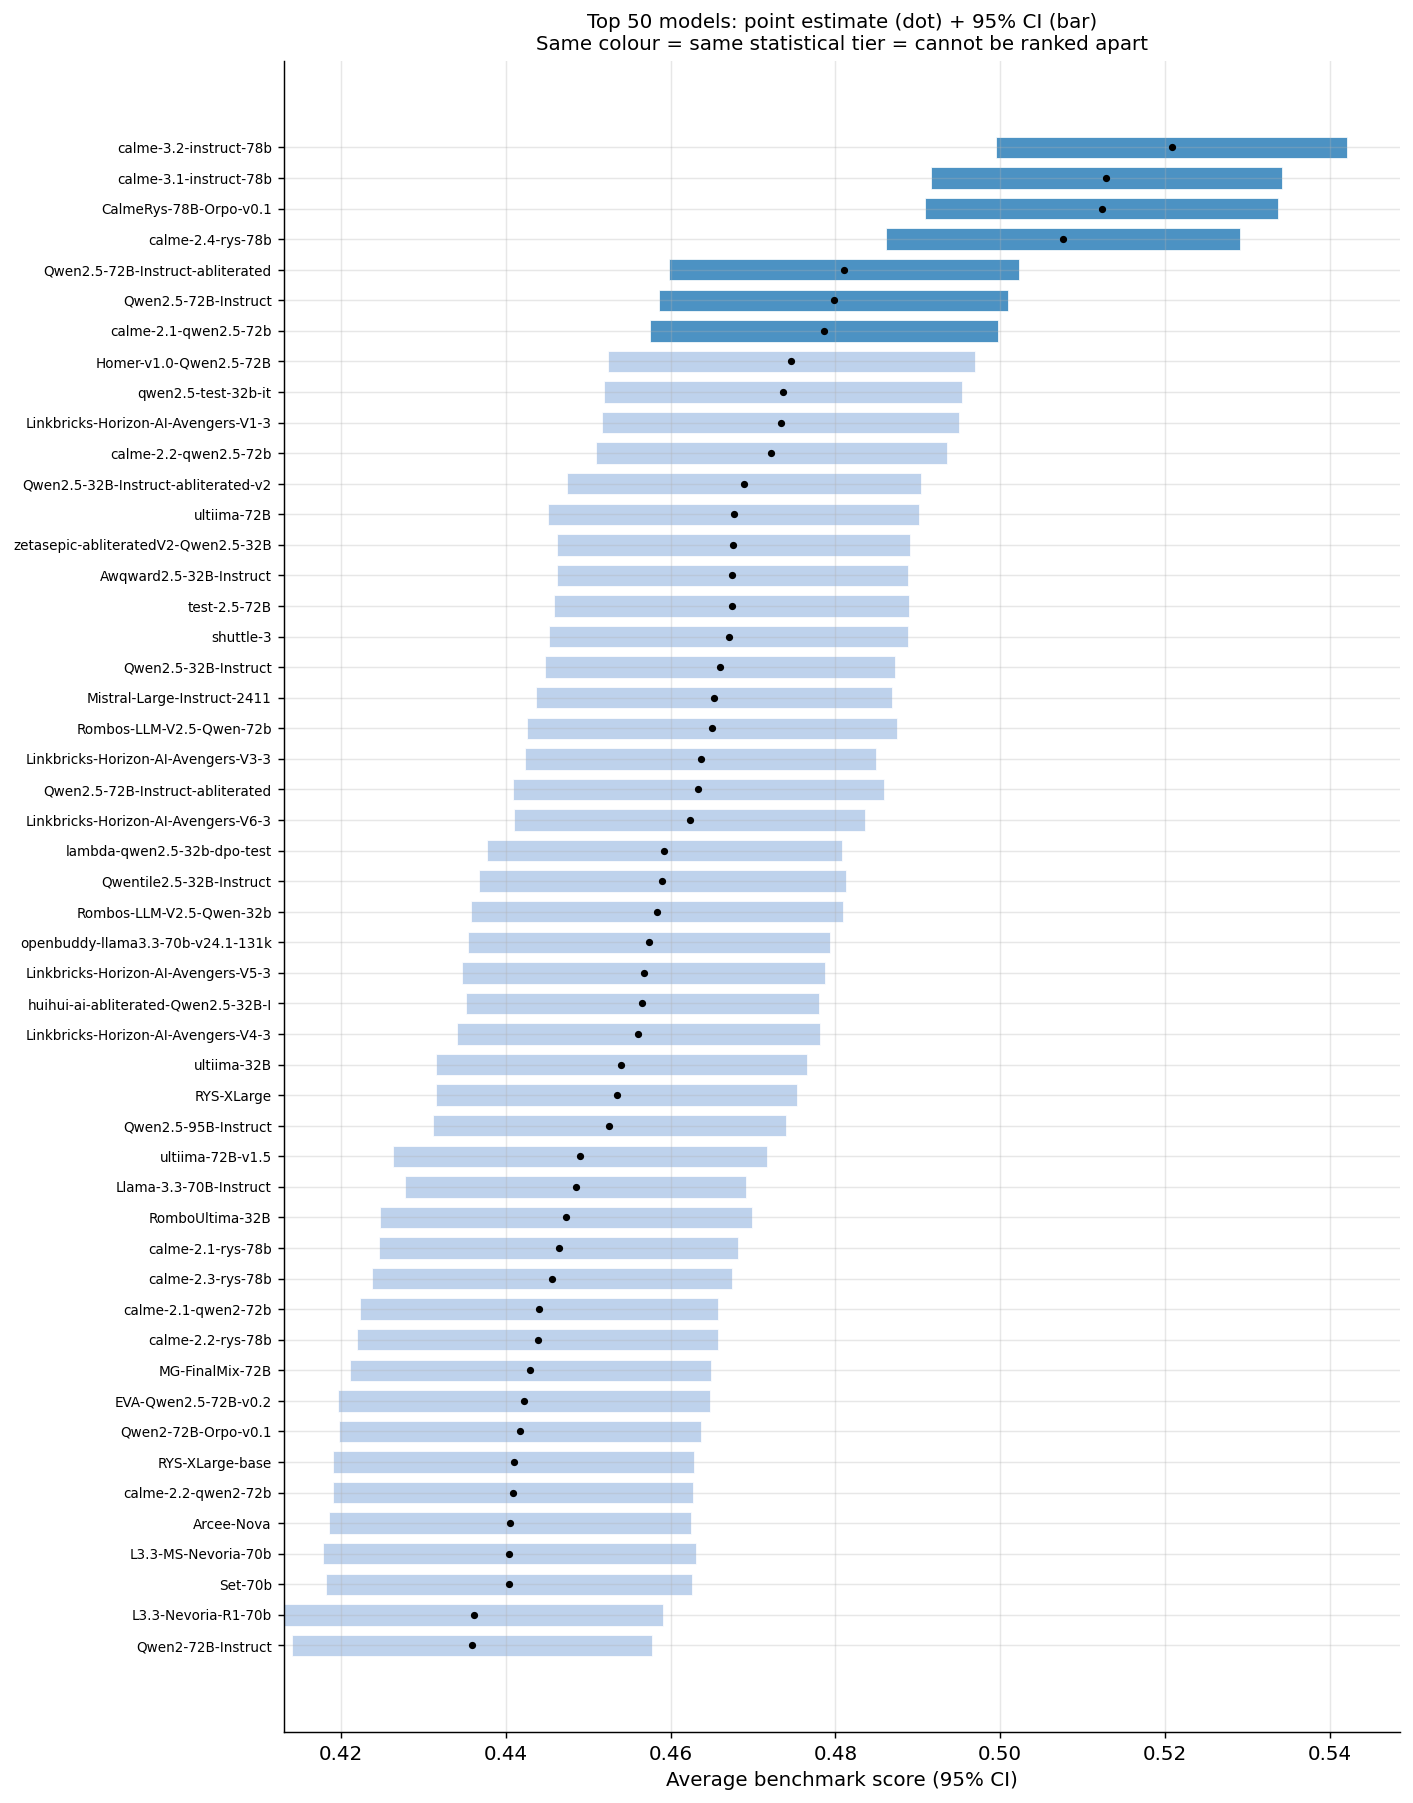

Saved fig2_top50_ci.png


In [30]:
top_n = 50
dt = df_valid.head(top_n).copy()
dt["short"] = dt["model"].str.split("/").str[-1].str[:35]

fig, ax = plt.subplots(figsize=(11, 14))
palette = plt.cm.tab20.colors
tier_colors = {t: palette[i % 20] for i, t in enumerate(dt["tier"].unique())}

for i, (_, row) in enumerate(dt.iterrows()):
    y = top_n - i
    ax.barh(y, row["avg_hi"]-row["avg_lo"], left=row["avg_lo"], height=0.7,
            color=tier_colors.get(row["tier"], "steelblue"), alpha=0.8,
            edgecolor="white", linewidth=0.5)
    ax.plot(row["avg_score"], y, "o", color="black", markersize=3, zorder=5)

ax.set_yticks(range(top_n, 0, -1))
ax.set_yticklabels(dt["short"].tolist(), fontsize=7.5)
ax.set_xlabel("Average benchmark score (95% CI)")
ax.set_title(f"Top {top_n} models: point estimate (dot) + 95% CI (bar)\n"
             "Same colour = same statistical tier = cannot be ranked apart", fontsize=11)
plt.tight_layout(); plt.savefig("fig2_top50_ci.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved fig2_top50_ci.png")

### 6c. How many real tiers are there?

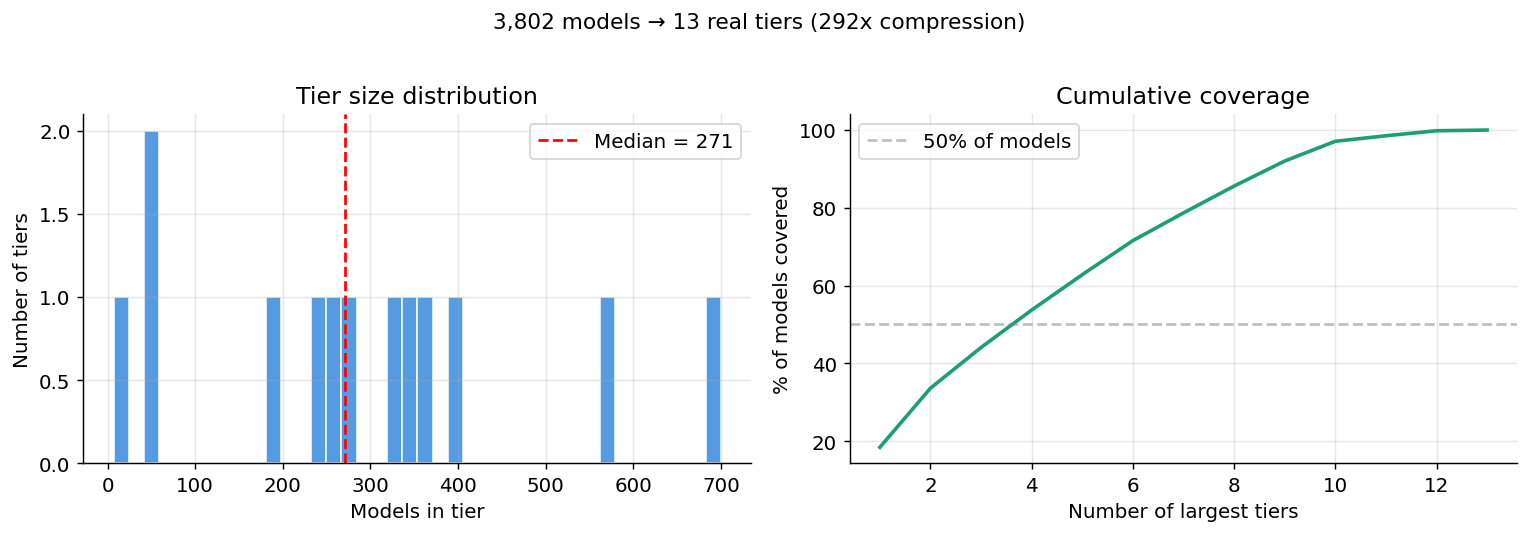

Saved fig3_tier_distribution.png


In [31]:
ts = df_valid["tier"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ts.values, bins=40, color="#378ADD", edgecolor="white", alpha=0.85)
axes[0].axvline(ts.median(), color="red", linestyle="--", label=f"Median = {ts.median():.0f}")
axes[0].set_xlabel("Models in tier"); axes[0].set_ylabel("Number of tiers")
axes[0].set_title("Tier size distribution"); axes[0].legend()

cum = ts.sort_values(ascending=False).cumsum() / n_models * 100
axes[1].plot(range(1, len(cum)+1), cum.values, color="#1D9E75", linewidth=2)
axes[1].axhline(50, color="gray", linestyle="--", alpha=0.5, label="50% of models")
axes[1].set_xlabel("Number of largest tiers"); axes[1].set_ylabel("% of models covered")
axes[1].set_title("Cumulative coverage"); axes[1].legend()

fig.suptitle(f"{n_models:,} models → {n_tiers:,} real tiers ({n_models/n_tiers:.0f}x compression)",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig("fig3_tier_distribution.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved fig3_tier_distribution.png")

---
## 7. Are the Six Benchmarks Measuring Different Things?

### 7a. Overall correlation

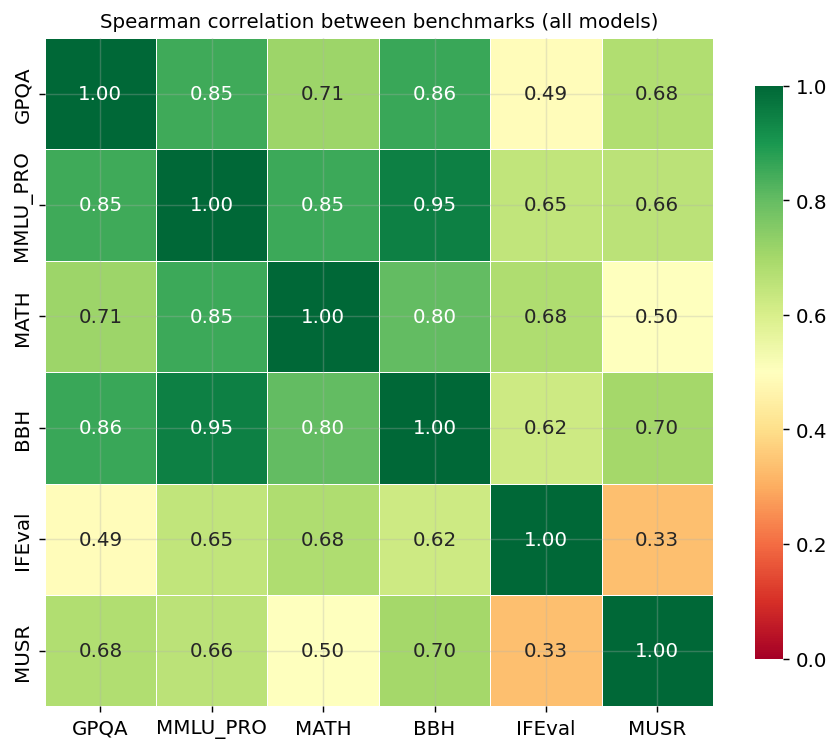

Highest correlations:
  MMLU_PRO   x BBH       : r = 0.948  ← redundant
  GPQA       x BBH       : r = 0.858
  MMLU_PRO   x MATH      : r = 0.852
  GPQA       x MMLU_PRO  : r = 0.850
  MATH       x BBH       : r = 0.802


In [32]:
corr = df_valid[bench_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Spearman correlation between benchmarks (all models)", fontsize=11)
plt.tight_layout(); plt.savefig("fig4_correlation_all.png", dpi=150, bbox_inches="tight"); plt.show()

pairs = []
for i, a in enumerate(bench_cols):
    for j, b in enumerate(bench_cols):
        if j > i: pairs.append((a, b, corr.loc[a, b]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("Highest correlations:")
for a, b, r in pairs[:5]:
    print(f"  {a:10s} x {b:10s}: r = {r:.3f}{'  ← redundant' if abs(r)>0.9 else ''}")

### 7b. Does the BBH × MMLU-PRO correlation collapse at the frontier?

If the 0.95 correlation is driven by scale (big models good at everything), it should weaken
when we compare models of similar size — where ranking precision matters most.

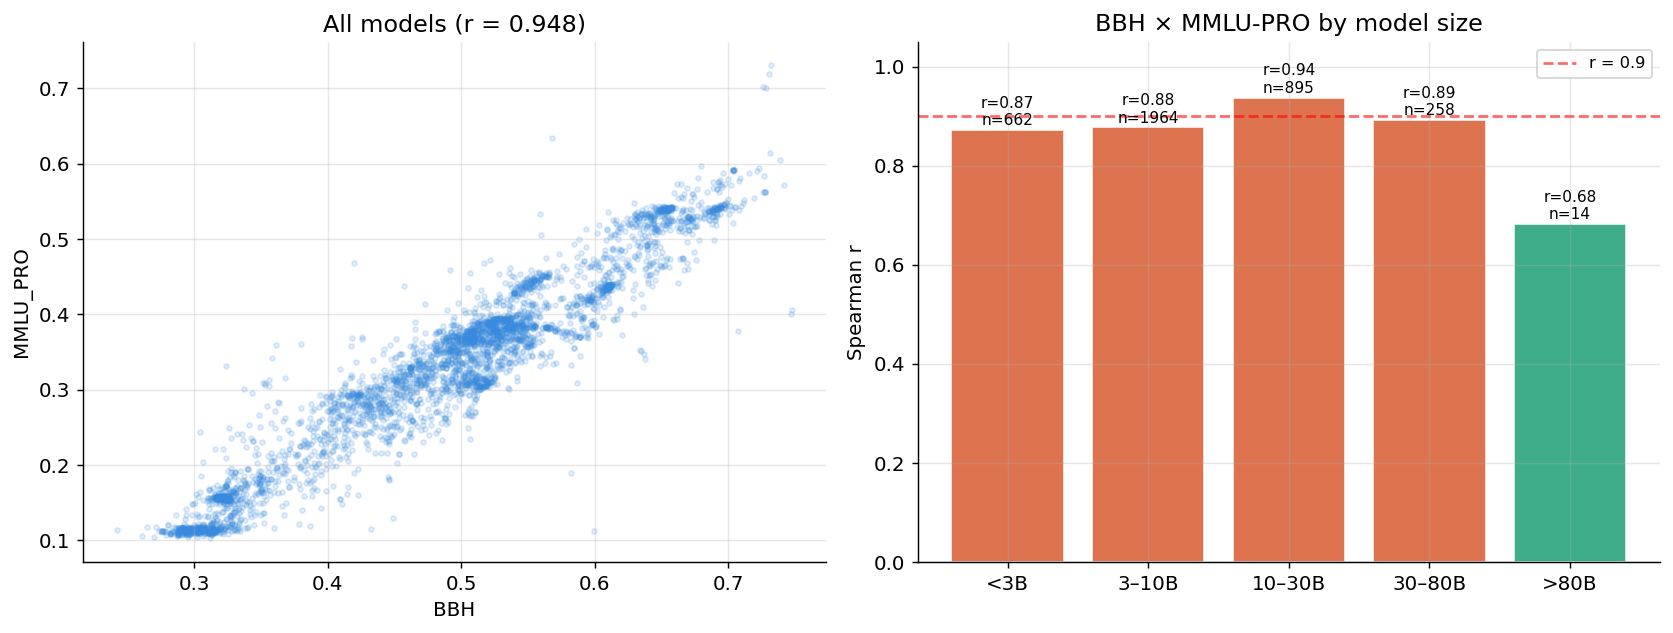

Correlation within size buckets:
  <3B     : r = 0.872 (n=662)
  3–10B   : r = 0.877 (n=1964)
  10–30B  : r = 0.937 (n=895)
  30–80B  : r = 0.892 (n=258)
  >80B    : r = 0.682 (n=14)


In [33]:
df_valid["size_tier"] = pd.cut(df_valid["params_b"],
    bins=[0, 3, 10, 30, 80, np.inf], labels=["<3B","3–10B","10–30B","30–80B",">80B"])
pair = ("BBH", "MMLU_PRO")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df_valid[pair[0]], df_valid[pair[1]], alpha=0.15, s=8, color="#378ADD")
r_all = df_valid[[pair[0], pair[1]]].dropna().corr(method="spearman").iloc[0,1]
axes[0].set_title(f"All models (r = {r_all:.3f})"); axes[0].set_xlabel(pair[0]); axes[0].set_ylabel(pair[1])

labels = ["<3B","3–10B","10–30B","30–80B",">80B"]
corrs, counts = [], []
for lab in labels:
    sub = df_valid[df_valid["size_tier"]==lab][[pair[0], pair[1]]].dropna()
    if len(sub) >= 10:
        corrs.append(sub.corr(method="spearman").iloc[0,1]); counts.append(len(sub))
    else:
        corrs.append(np.nan); counts.append(0)
bar_colors = ["#D85A30" if (not np.isnan(r) and r > 0.85) else "#1D9E75" for r in corrs]
bars = axes[1].bar(labels, corrs, color=bar_colors, edgecolor="white", alpha=0.85)
axes[1].axhline(0.9, color="red", linestyle="--", alpha=0.6, label="r = 0.9")
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("Spearman r")
axes[1].set_title("BBH × MMLU-PRO by model size"); axes[1].legend(fontsize=9)
for bar, r, n in zip(bars, corrs, counts):
    if not np.isnan(r):
        axes[1].text(bar.get_x()+bar.get_width()/2, r+0.01, f"r={r:.2f}\nn={n}", ha="center", fontsize=8.5)
plt.tight_layout(); plt.savefig("fig5_correlation_by_size.png", dpi=150, bbox_inches="tight"); plt.show()

print("Correlation within size buckets:")
for lab, r, n in zip(labels, corrs, counts):
    if not np.isnan(r):
        print(f"  {lab:8s}: r = {r:.3f} (n={n})")

---
## 8. The Before / After Comparison

For the top 100 models: original rank, statistical tier, and how many models share that tier.
A large tier means the leaderboard is presenting noise as signal.

In [34]:
top100 = df_valid.head(100).copy()
top100["short"]     = top100["model"].str.split("/").str[-1].str[:45]
top100["tier_size"] = top100["tier"].map(top100["tier"].value_counts())
top100["score_pct"] = (top100["avg_score"]*100).round(2)
top100["ci"]        = top100.apply(lambda r: f"[{r.avg_lo*100:.1f}, {r.avg_hi*100:.1f}]", axis=1)

show = top100[["orig_rank","tier","tier_size","short","score_pct","ci"]].copy()
show.columns = ["Original Rank","Statistical Tier","Models in Tier","Model","Score %","95% CI"]
show.to_csv("leaderboard_corrected_top100.csv", index=False)

print(f"Top 100 models collapse into {top100['tier'].nunique()} statistical tiers\n")
print(show.to_string(index=False))

Top 100 models collapse into 3 statistical tiers

 Original Rank  Statistical Tier  Models in Tier                                         Model  Score %       95% CI
             1                 1               7                        calme-3.2-instruct-78b    52.08 [50.0, 54.2]
             2                 1               7                        calme-3.1-instruct-78b    51.29 [49.2, 53.4]
             3                 1               7                        CalmeRys-78B-Orpo-v0.1    51.23 [49.1, 53.4]
             4                 1               7                             calme-2.4-rys-78b    50.77 [48.6, 52.9]
             5                 1               7              Qwen2.5-72B-Instruct-abliterated    48.11 [46.0, 50.2]
             6                 1               7                          Qwen2.5-72B-Instruct    47.98 [45.9, 50.1]
             7                 1               7                         calme-2.1-qwen2.5-72b    47.86 [45.7, 50.0]
             8

---
## 9. Does Removing MUSR Change Anything?

We earlier suspected MUSR's subtask structure inflates uncertainty. Now that we use clustered
SEs, we can test directly: does dropping MUSR tighten the combined CI and produce more tiers?

In [35]:
non_musr = [b for b in bench_cols if b != "MUSR"]
idx = [bench_cols.index(b) for b in non_musr]
corr_nm = df_valid[non_musr].corr(method="pearson").values
k_nm = len(non_musr)
SE_nm = df_valid[[f"{b}_se" for b in non_musr]].values

avg_se_nm = np.array([
    np.sqrt((row[None,:] * corr_nm * row[:,None]).sum()) / k_nm for row in SE_nm
])
df_valid["avg_lo_nm"] = df_valid["avg_score"] - Z * avg_se_nm
df_valid["avg_hi_nm"] = df_valid["avg_score"] + Z * avg_se_nm

w_with    = (df_valid["avg_width"].median()) * 100
w_without = (df_valid["avg_hi_nm"] - df_valid["avg_lo_nm"]).median() * 100
print(f"Median CI half-width WITH MUSR:    ±{w_with/2:.3f}pp")
print(f"Median CI half-width WITHOUT MUSR: ±{w_without/2:.3f}pp")
print(f"Change: {((w_with-w_without)/w_with)*100:+.1f}%")

dn = df_valid.sort_values("avg_score", ascending=False).reset_index(drop=True)
def tiers_cols(d, lo, hi):
    out, tid = [], 1; a = d.iloc[0][lo]
    for _, r in d.iterrows():
        if r[hi] < a: tid += 1; a = r[lo]
        out.append(tid)
    return out
dn["tier_nm"] = tiers_cols(dn, "avg_lo_nm", "avg_hi_nm")
print(f"\nTiers WITH MUSR:    {n_tiers}")
print(f"Tiers WITHOUT MUSR: {dn['tier_nm'].max()}")

Median CI half-width WITH MUSR:    ±2.085pp
Median CI half-width WITHOUT MUSR: ±2.019pp
Change: +3.2%

Tiers WITH MUSR:    13
Tiers WITHOUT MUSR: 14


---
## 10. Conclusions

### What we found

**Finding 1 — The leaderboard has thousands of ranks. Statistically, it has far fewer and this is a floor.**
With clustered standard errors, correlation-aware propagation, and strict overlap-based tiering,
the models collapse into a small number of statistically distinguishable tiers. Every modelling
choice is conservative: clustered SEs are wider than naive ones, and correlated benchmarks inflate
the variance of the average. Correcting these *reduces* the number of real tiers. The count we
report is a floor on the collapse, not a ceiling.

**Finding 2 — BBH and MMLU-PRO are nearly redundant at population level (~0.95), but this is a scale artifact.**
Across all models the two benchmarks correlate at ~0.95, so equal-weighting them double-counts one
signal. But this is driven by model scale — within the >80B frontier tier the correlation drops
substantially, suggesting the benchmarks *do* measure different things exactly where ranking
precision matters most. The leaderboard's equal weighting ignores this.

**Finding 3 — The precision bottleneck is question count, not any single benchmark.**
Removing MUSR does not meaningfully improve resolution. GPQA (448 questions) and IFEval (541 prompts)
are the largest per-benchmark uncertainty contributors. The combined average simply cannot resolve
models that differ by less than a few percentage points.

### What this means

The field cites leaderboard positions to justify architecture, training, and deployment decisions.
A large fraction of those position differences are below the threshold of statistical significance.
We are reading thousands of significant figures from a ruler with far fewer real tick marks.

### What should change

1. **Display CIs, not just point estimates.** A model ranked #47 that is statistically identical to #112 should be shown as such.
2. **GPQA needs more questions.** At 448 it is a precision bottleneck.
3. **Equal weighting needs justification.** BBH and MMLU-PRO at 0.95 correlation double-count one dimension.
4. **Correlation structure should inform weighting**, especially at the frontier where benchmarks diverge.

---

## Limitations (read before citing)

- **IFEval is treated as a flat proportion.** Its true structure nests verifiable instructions inside
  prompts; modelling that clustering would *widen* its interval. Our IFEval CI is therefore mildly
  anti-conservative (too narrow). This makes our overall tier count, if anything, an overcount and the
  true collapse is at least as strong.
- **Clustered SEs assume subtasks are the clustering unit.** Within-subtask question correlation
  (e.g. multiple MUSR questions per narrative) is not separately modelled; the per-subtask stderrs
  from the harness are taken as given.
- **The correlation matrix is estimated on the population of models** and applied uniformly. A more
  refined analysis would estimate it within capability tiers.
- **We use the latest result file per model.** Where a model was re-evaluated, earlier runs are ignored.
- This is an **audit of existing public data**, not a new evaluation. No models were re-run.

---
*Data: Open LLM Leaderboard v2 (HuggingFace, archived March 2025). Methods follow Miller (2024),
"Adding Error Bars to Evals.".*